# **📌 Fake Job Postings Detection : Using ML,DL and Transformer Architectures**

# **⚡Objective**

**To develop an intelligent and reliable system capable of identifying fraudulent or misleading job advertisements from genuine employment opportunities. The project aims to analyze relevant features of job postings—such as job title, description, company information, requirements, benefits, and other textual attributes—to detect patterns commonly associated with fake listings.**

**By applying data preprocessing, natural language processing (NLP), feature engineering, and machine learning techniques, the system seeks to classify job postings as legitimate or potentially fraudulent with high accuracy. The ultimate goal is to help job seekers make safer decisions, reduce exposure to employment scams, and demonstrate how artificial intelligence can be applied to address real-world cybersecurity and trust-related challenges in online recruitment.**

**1. Import The Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from wordcloud import WordCloud,STOPWORDS
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Embedding,Dropout,Bidirectional,LSTM,GRU,GlobalMaxPool1D
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping
from datasets import Dataset
from transformers import AutoTokenizer,AutoModelForSequenceClassification,TrainingArguments,Trainer,DataCollatorWithPadding
from sklearn.metrics import accuracy_score,f1_score
import torch

**2. Load the Dataset**

In [2]:
df = pd.read_csv('/content/sample_data/fake_job_postings.csv.zip')

**3. EDA and Data Preprocessing**

- *Handling NULL values*

- *Analyzing the reasons of fake jobs*

- *Cleaning the data*

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape

(17880, 18)

In [5]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [6]:
df.dropna(subset=['description'], inplace=True)

In [7]:
df.shape

(17879, 18)

In [8]:
cols = ['job_id','department','salary_range','telecommuting','function']
df.drop(columns=cols,axis=1,inplace=True)

In [9]:
df.head()

,title,location,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,fraudulent
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,1,0,Other,Internship,NaN,NaN,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,1,0,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,0
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,0


In [10]:
df.shape

(17879, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17879 entries, 0 to 17879
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17879 non-null  object
 1   location             17533 non-null  object
 2   company_profile      14572 non-null  object
 3   description          17879 non-null  object
 4   requirements         15184 non-null  object
 5   benefits             10668 non-null  object
 6   has_company_logo     17879 non-null  int64 
 7   has_questions        17879 non-null  int64 
 8   employment_type      14409 non-null  object
 9   required_experience  10830 non-null  object
 10  required_education   9775 non-null   object
 11  industry             12977 non-null  object
 12  fraudulent           17879 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 1.9+ MB


In [12]:
df.isnull().sum()

,0
title,0
location,346
company_profile,3307
description,0
requirements,2695
benefits,7211
has_company_logo,0
has_questions,0
employment_type,3470
required_experience,7049


In [13]:
for i in df.columns:
    if i not in ['has_company_logo', 'has_questions', 'description']:
        df[i].fillna('Unknown', inplace=True)

/tmp/ipykernel_848/2509699914.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna('Unknown', inplace=True)


In [14]:
df.isnull().sum()

,0
title,0
location,0
company_profile,0
description,0
requirements,0
benefits,0
has_company_logo,0
has_questions,0
employment_type,0
required_experience,0


In [ ]:
for column in df.columns :
  if column in ['location', 'has_questions', 'has_company_logo','employment_type','required_experience','required_education','industry'] :
    print(f"{column} Total Unique Values : {df[column].nunique()}")
    print(f"{column} Unique Values : {df[column].unique()}")
    print("\n")

location Total Unique Values : 3106
location Unique Values : ['US, NY, New York' 'NZ, , Auckland' 'US, IA, Wever' ...
 'US, CA, los Angeles' 'CA, , Ottawa' 'GB, WSX, Chichester']


has_company_logo Total Unique Values : 2
has_company_logo Unique Values : [1 0]


has_questions Total Unique Values : 2
has_questions Unique Values : [0 1]


employment_type Total Unique Values : 6
employment_type Unique Values : ['Other' 'Full-time' 'Unknown' 'Part-time' 'Contract' 'Temporary']


required_experience Total Unique Values : 8
required_experience Unique Values : ['Internship' 'Not Applicable' 'Unknown' 'Mid-Senior level' 'Associate'
 'Entry level' 'Executive' 'Director']


required_education Total Unique Values : 14
required_education Unique Values : ['Unknown' "Bachelor's Degree" "Master's Degree"
 'High School or equivalent' 'Unspecified'
 'Some College Coursework Completed' 'Vocational' 'Certification'
 'Associate Degree' 'Professional' 'Doctorate'
 'Some High School Coursework' 'Vocational 

In [ ]:
df.columns

Index(['title', 'location', 'company_profile', 'description', 'requirements',
       'benefits', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'fraudulent'],
      dtype='object')

In [ ]:
df1 = df.copy()

**4. Data Preparation**

In [15]:
df['combined_text'] = (
    "[TITLE] " + df['title'] + " " +
    "[COMPANY_PROFILE] " + df['company_profile'] + " " +
    "[DESCRIPTION] " + df['description'] + " " +
    "[REQUIREMENTS] " + df['requirements'] + " " +
    "[BENEFITS] " + df['benefits']
)

In [16]:
df.head()

,title,location,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,fraudulent,combined_text
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Unknown,1,0,Other,Internship,Unknown,Unknown,0,[TITLE] Marketing Intern [COMPANY_PROFILE] We'...
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,0,[TITLE] Customer Service - Cloud Video Product...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Unknown,1,0,Unknown,Unknown,Unknown,Unknown,0,[TITLE] Commissioning Machinery Assistant (CMA...
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,0,[TITLE] Account Executive - Washington DC [COM...
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,0,[TITLE] Bill Review Manager [COMPANY_PROFILE] ...


In [ ]:
print(f"Median length : {df['combined_text'].str.len().median()}")
print(f"Max length : {df['combined_text'].str.len().max()}")
print(f"Min length : {df['combined_text'].str.len().min()}")

Median length : 2594.0
Max length : 15032
Min length : 113


**5. Data Cleaning**

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

stopword = set(stopwords.words('english'))
neg_words = {'no', 'not', 'never','nor', 'without', 'none', 'with', 'by','you', 'we', 'our', 'i', 'us' ,
             'yes' ,"aren't", "couldn't", "didn't", "doesn't","hadn't", "hasn't", "haven't", "isn't",
              "mightn't", "mustn't", "needn't","shan't", "shouldn't", "wasn't","weren't", "won't", "wouldn't", "don't"}
stopword = stopword - neg_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [17]:
def pre_process(text) :
  txt = text.lower()
  txt = re.sub(r'<.*?>', ' ' , txt)
  txt = re.sub(r'https?://\S+|www\.\S+', ' ', txt)
  txt = re.sub(r'\S+@\S+', ' ' , txt)
  txt = re.sub(r"[^a-z0-9\s.,!?;:'\"()\+-\[\]]"," ",txt)
  txt = re.sub(r'\s+',' ',txt).strip()
  return txt

In [18]:
df['combined_text'] = df['combined_text'].apply(pre_process)

In [ ]:
print(f"Median length : {df['combined_text'].str.len().median()}")
print(f"Max length : {df['combined_text'].str.len().max()}")
print(f"Min length : {df['combined_text'].str.len().min()}")

Median length : 2569.0
Max length : 14968
Min length : 113


In [ ]:
df.columns

Index(['title', 'location', 'company_profile', 'description', 'requirements',
       'benefits', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'fraudulent',
       'combined_text'],
      dtype='object')

**6. 📊Text Analysis and Visualization**

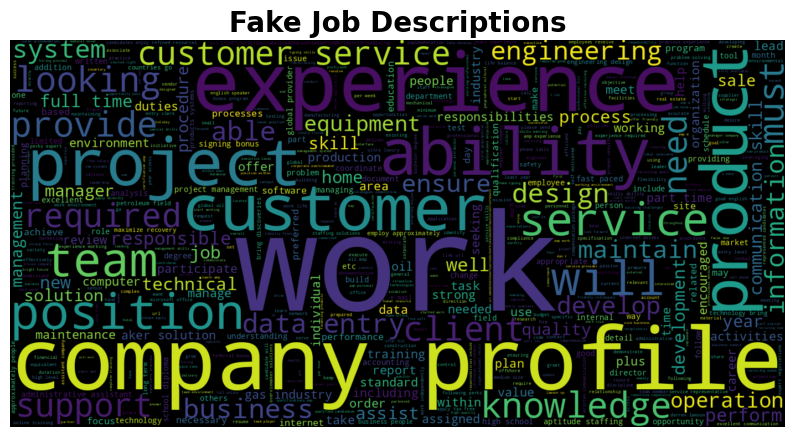

In [ ]:
plt.figure(figsize=(10, 6))

txt = " ".join(df[df.fraudulent == 1].combined_text.astype(str))

remove_words = {
    'description', 'company_profile', 'benefits',
    'title', 'unknown', 'requirements'
}

stopwords = set(STOPWORDS).union(remove_words)

word_cloud = WordCloud(max_words=1500,width=1400,height=700,stopwords=stopwords).generate(txt)
plt.title("Fake Job Descriptions",fontweight='bold',fontsize=20)
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis('off')
plt.show()

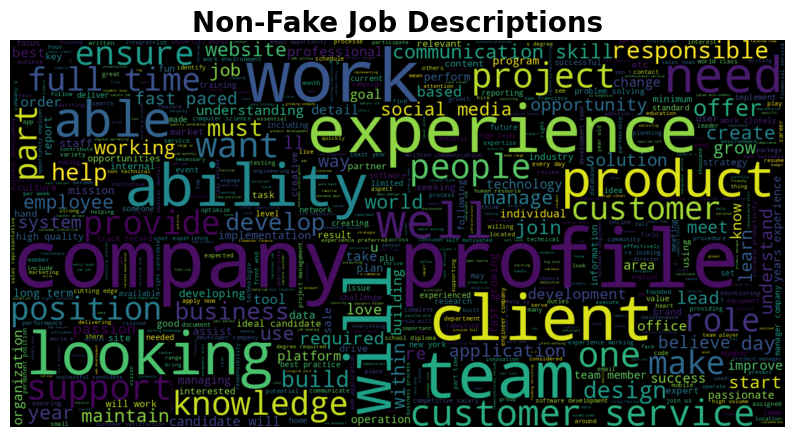

In [ ]:
plt.figure(figsize=(10, 6))

txt = " ".join(df[df.fraudulent == 0].combined_text.astype(str))

remove_words = {
    'description', 'company_profile', 'benefits',
    'title', 'unknown', 'requirements'
}

stopword = set(STOPWORDS).union(remove_words)

word_cloud = WordCloud(max_words=1500,width=1400,height=700,stopwords=stopword).generate(txt)
plt.title("Non-Fake Job Descriptions",fontweight='bold',fontsize=20)
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis('off')
plt.show()

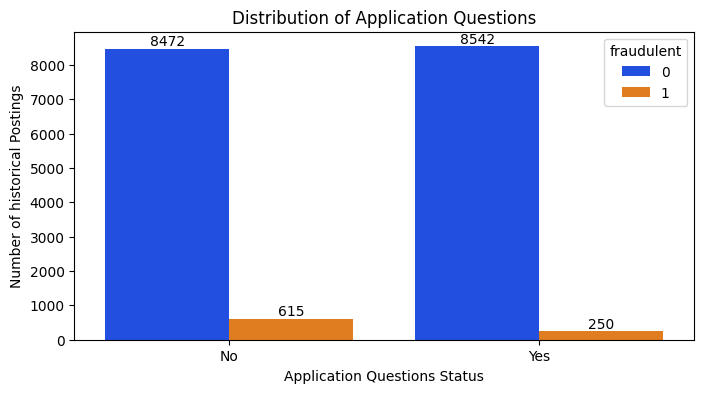

In [38]:
plt.figure(figsize=(8, 4))
plot = sns.countplot(data=df, x='has_questions', hue='fraudulent' , palette='bright')
for i in plot.containers :
  plot.bar_label(i)
plt.title('Distribution of Application Questions')
plt.xlabel('Application Questions Status')
plt.ylabel('Number of historical Postings')
plt.show()

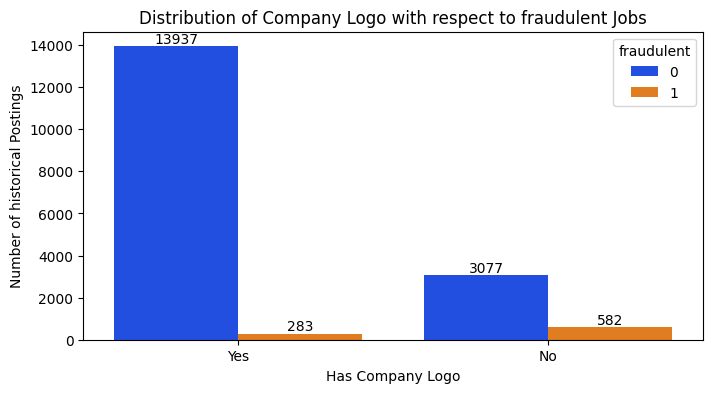

In [36]:
plt.figure(figsize=(8, 4))
plot = sns.countplot(data=df, x='has_company_logo', hue='fraudulent',palette="bright")
for i in plot.containers :
  plot.bar_label(i)
plt.title('Distribution of Company Logo with respect to fraudulent Jobs')
plt.xlabel('Has Company Logo')
plt.ylabel('Number of historical Postings')
plt.show()

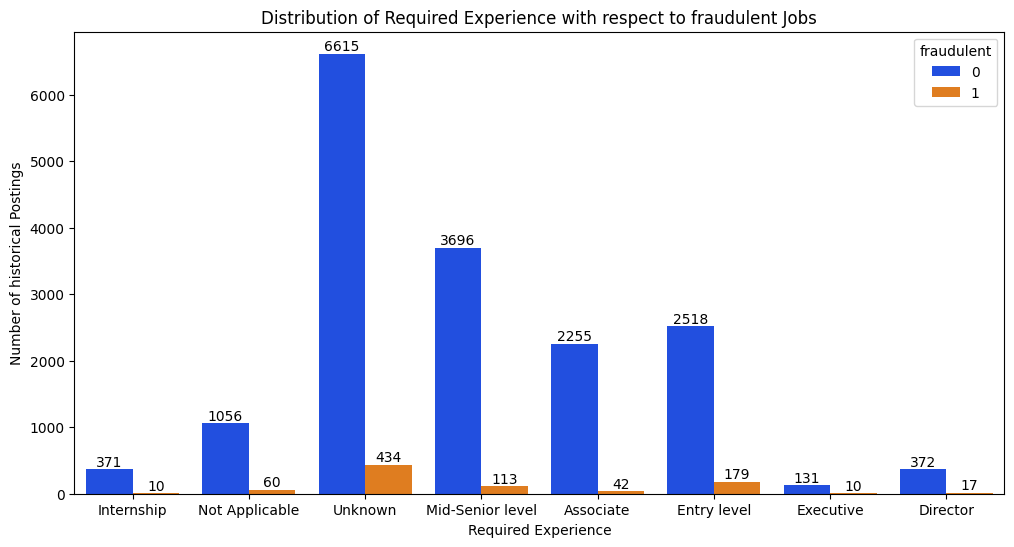

In [39]:
plt.figure(figsize=(12, 6))
plot = sns.countplot(data=df, x='required_experience', hue='fraudulent' , palette='bright')
for i in plot.containers :
  plot.bar_label(i)
plt.title('Distribution of Required Experience with respect to fraudulent Jobs')
plt.xlabel('Required Experience')
plt.ylabel('Number of historical Postings')
plt.show()

# **📖Version A : Using ML Algorithms and Artificial Neural Networks (Tabular form)**

In [ ]:
X = df.drop(columns=['title','location','company_profile','description','requirements','benefits','required_education','industry','fraudulent'])
Y = df['fraudulent']

In [ ]:
X

,has_company_logo,has_questions,employment_type,required_experience,combined_text
0,1,0,Other,Internship,[title] marketing intern [company profile] we'...
1,1,0,Full-time,Not Applicable,[title] customer service - cloud video product...
2,1,0,Unknown,Unknown,[title] commissioning machinery assistant (cma...
3,1,0,Full-time,Mid-Senior level,[title] account executive - washington dc [com...
4,1,1,Full-time,Mid-Senior level,[title] bill review manager [company profile] ...
...,...,...,...,...,...
17875,1,1,Full-time,Mid-Senior level,[title] account director - distribution [compa...
17876,1,1,Full-time,Mid-Senior level,[title] payroll accountant [company profile] w...
17877,0,0,Full-time,Unknown,[title] project cost control staff engineer - ...
17878,0,1,Contract,Not Applicable,[title] graphic designer [company profile] unk...


In [ ]:
Y

,fraudulent
0,0
1,0
2,0
3,0
4,0
...,...
17875,0
17876,0
17877,0
17878,0


In [ ]:
Y.value_counts()

,count
fraudulent,
0,17014
1,865


In [ ]:
X['combined_text'][0]

"[title] marketing intern [company profile] we're food52, and we've created a groundbreaking and award-winning cooking site. we support, connect, and celebrate home cooks, and give them everything they need in one place.we have a top editorial, business, and engineering team. we're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. we attract the most talented home cooks and contributors in the country; we also publish well-known professionals like mario batali, gwyneth paltrow, and danny meyer. and we have partnerships with whole foods market and random house.food52 has been named the best food website by the james beard foundation and iacp, and has been featured in the new york times, npr, pando daily, techcrunch, and on the today show.we're located in chelsea, in new york city. [description] food52, a fast-growing, james beard award-winning online

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.1,stratify=Y,random_state=42)

In [ ]:
X_train

,has_company_logo,has_questions,employment_type,required_experience,combined_text
1494,1,0,Full-time,Entry level,[title] job vacancies at montcalm luxury hotel...
4754,1,0,Full-time,Mid-Senior level,"[title] international broadcaster, swahili lan..."
13094,0,0,Full-time,Unknown,[title] sales representative [company profile]...
311,1,0,Part-time,Entry level,[title] customer service associate - part time...
5320,1,1,Full-time,Not Applicable,[title] engagement marketing manager [company ...
...,...,...,...,...,...
1841,1,1,Contract,Associate,[title] public relations manager [company prof...
11852,1,1,Unknown,Unknown,[title] ios developer [company profile] tizu i...
10870,1,0,Full-time,Entry level,[title] database researcher [company profile] ...
565,1,0,Full-time,Entry level,[title] customer service associate [company pr...


In [ ]:
Y_train.value_counts()

,count
fraudulent,
0,15313
1,778


### 🚀**Data Preprocessing :**

**1. Tf-Idf Vectorization : For NLP Text data**

**2. One-Hot-Encoding : For Categorical data**


In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('text',TfidfVectorizer(ngram_range=(1,2),stop_words=list(stopword),max_features=30000),'combined_text'),
        ('encoder',OneHotEncoder(sparse_output=True,drop=['Unknown','Unknown'],handle_unknown='ignore'),['employment_type','required_experience'])
    ],
    remainder = 'passthrough'
)

In [ ]:
X_train_final = processor.fit_transform(X_train)
X_test_final = processor.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['we', 'you'] not in stop_words.
  warnings.warn(


In [ ]:
X_train_final

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4539919 stored elements and shape (16091, 30014)>

**1.1 Training ML Algorithms**

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced',penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced',max_depth=6,min_samples_leaf=6,max_features='sqrt',random_state=42),
    'NB' : ComplementNB(),
    'BernoulliNB' : BernoulliNB(),
    'KNN' : KNeighborsClassifier(weights='distance',n_neighbors=15),
    'SVM' : SVC(class_weight='balanced',C=1,random_state=42),
    'RF' : RandomForestClassifier(n_estimators=150,class_weight='balanced',max_depth=8,min_samples_leaf=5,max_features='sqrt',random_state=42),
    'XGB' : XGBClassifier(n_estimators=150,scale_pos_weight=1.5,max_depth=5,learning_rate=0.06,colsample_bytree=0.6,subsample=0.7,random_state=42)
}

for name , model in models.items() :
  model.fit(X_train_final,Y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
NB trained successfully.
BernoulliNB trained successfully.
KNN trained successfully.
SVM trained successfully.
RF trained successfully.
XGB trained successfully.


In [ ]:
for name,model in models.items() :
  Y_pred = model.predict(X_test_final)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_final,Y_train)}")
  print(f"Testing score = {model.score(X_test_final,Y_test)}")
  print("\n")
  print("Classification Report : ")
  print(classification_report(Y_test,Y_pred))
  print("\n")
  print(confusion_matrix(Y_test,Y_pred))
  if name != 'SVM' :
    prob = model.predict_proba(X_test_final)[:,1]
    print(f"PR-AUC score : {average_precision_score(Y_test,prob)}")
    print(f"ROC score = {roc_auc_score(Y_test,prob)}")
  else :
    scores = model.decision_function(X_test_final)
    print(f"PR-AUC score : {average_precision_score(Y_test,scores)}")
    print(f"ROC score = {roc_auc_score(Y_test,scores)}")
  print("\n")

Logistic Regression metrics : 

Training score = 0.9778136846684482
Testing score = 0.9725950782997763


Classification Report : 
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1701
           1       0.64      0.98      0.78        87

    accuracy                           0.97      1788
   macro avg       0.82      0.97      0.88      1788
weighted avg       0.98      0.97      0.98      1788



[[1654   47]
 [   2   85]]
PR-AUC score : 0.9578762200510054
ROC score = 0.9974051774818057


Decision Tree metrics : 

Training score = 0.8696787023802125
Testing score = 0.8652125279642058


Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.88      0.93      1701
           1       0.18      0.49      0.26        87

    accuracy                           0.87      1788
   macro avg       0.58      0.69      0.59      1788
weighted avg       0.93      0.87      0.89      17

**1.2 Training ANNs**

In [ ]:
X_train_final.shape

(16091, 30014)

In [ ]:
input_feature = X_train_final.shape[1]

**Using Class Weights to handle Imbalanced data**

In [ ]:
classes = np.unique(Y_train)
weights = compute_class_weight(class_weight='balanced',classes=classes,y=Y_train)
class_weights = dict(zip(classes,weights))
print(class_weights)

{np.int64(0): np.float64(0.5254032521387056), np.int64(1): np.float64(10.341259640102828)}


In [ ]:
model1 = Sequential()
model1.add(Dense(256,input_dim=input_feature,activation="relu",kernel_regularizer=L2()))
model1.add(Dropout(0.3))
model1.add(Dense(128,activation="relu",kernel_regularizer=L2()))
model1.add(Dropout(0.3))
model1.add(Dense(64,activation="relu",kernel_regularizer=L2()))
model1.add(Dropout(0.3))
model1.add(Dense(1,activation="sigmoid"))

model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
his = model1.fit(X_train_final,Y_train,batch_size=300,epochs=8,validation_data=(X_test_final,Y_test),class_weight=class_weights,callbacks=EarlyStopping(patience=2,restore_best_weights=True))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.8722 - loss: 3.0215 - val_accuracy: 0.8412 - val_loss: 1.2927
Epoch 2/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.8663 - loss: 0.9339 - val_accuracy: 0.9172 - val_loss: 0.6169
Epoch 3/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8956 - loss: 0.6027 - val_accuracy: 0.9083 - val_loss: 0.5154
Epoch 4/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9065 - loss: 0.4969 - val_accuracy: 0.9435 - val_loss: 0.4101
Epoch 5/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9213 - loss: 0.4473 - val_accuracy: 0.9167 - val_loss: 0.4592
Epoch 6/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9266 - loss: 0.4251 - val_accuracy: 0.8949 - val_loss: 0.4962


In [ ]:
model1.evaluate(X_test_final,Y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - accuracy: 0.9435 - loss: 0.4101


[0.4100992679595947, 0.9435123205184937]

In [ ]:
Y_pred = model1.predict(X_test_final)
prediction = (Y_pred >= 0.5).astype(int)
print(classification_report(Y_test,prediction,target_names=['Class 0','Class 1']))
print(confusion_matrix(Y_test,prediction))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

     Class 0       1.00      0.95      0.97      1701
     Class 1       0.46      0.91      0.61        87

    accuracy                           0.94      1788
   macro avg       0.73      0.93      0.79      1788
weighted avg       0.97      0.94      0.95      1788

[[1608   93]
 [   8   79]]


**Tuning the Threshold to find best metrics**

In [ ]:
Y_pred = model1.predict(X_test_final)
prediction = (Y_pred >= 0.7).astype(int)
print(classification_report(Y_test,prediction,target_names=['Class 0','Class 1']))
print(confusion_matrix(Y_test,prediction))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

     Class 0       0.99      0.98      0.98      1701
     Class 1       0.66      0.80      0.73        87

    accuracy                           0.97      1788
   macro avg       0.83      0.89      0.85      1788
weighted avg       0.97      0.97      0.97      1788

[[1665   36]
 [  17   70]]


# **📖Version B : Using Neural Networks (ANNs,BiLSTMs,BiGRUs)**

In [ ]:
df1.isnull().sum()

,0
title,0
location,0
company_profile,0
description,0
requirements,0
benefits,0
has_company_logo,0
has_questions,0
employment_type,0
required_experience,0


**Data Preparation For Neural Networks(Sequential)**

In [ ]:
df1['has_company_logo'].replace({1 : 'Yes',0 : 'No'},inplace=True)
df1['has_questions'].replace({1 : 'Yes',0 : 'No'},inplace=True)

/tmp/ipykernel_5866/1353478104.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['has_company_logo'].replace({1 : 'Yes',0 : 'No'},inplace=True)
/tmp/ipykernel_5866/1353478104.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
df1

,title,location,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,fraudulent
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Unknown,Yes,No,Other,Internship,Unknown,Unknown,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Yes,No,Full-time,Not Applicable,Unknown,Marketing and Advertising,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Unknown,Yes,No,Unknown,Unknown,Unknown,Unknown,0
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Yes,No,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,0
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Yes,Yes,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,Account Director - Distribution,"CA, ON, Toronto",Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,Yes,Yes,Full-time,Mid-Senior level,Unknown,Computer Software,0
17876,Payroll Accountant,"US, PA, Philadelphia",WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,Yes,Yes,Full-time,Mid-Senior level,Bachelor's Degree,Internet,0
17877,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,Unknown,No,No,Full-time,Unknown,Unknown,Unknown,0
17878,Graphic Designer,"NG, LA, Lagos",Unknown,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,No,Yes,Contract,Not Applicable,Professional,Graphic Design,0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17879 entries, 0 to 17879
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17879 non-null  object
 1   location             17879 non-null  object
 2   company_profile      17879 non-null  object
 3   description          17879 non-null  object
 4   requirements         17879 non-null  object
 5   benefits             17879 non-null  object
 6   has_company_logo     17879 non-null  object
 7   has_questions        17879 non-null  object
 8   employment_type      17879 non-null  object
 9   required_experience  17879 non-null  object
 10  required_education   17879 non-null  object
 11  industry             17879 non-null  object
 12  fraudulent           17879 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 1.9+ MB


In [ ]:
df1['text'] = (
    "[TITLE] " + df1['title'] + " " +
    "[COMPANY_PROFILE] " + df1['company_profile'] + " " +
    "[DESCRIPTION] " + df1['description'] + " " +
    "[REQUIREMENTS] " + df1['requirements'] + " " +
    "[BENEFITS] " + df1['benefits'] + " " +
    "[HAS_COMPANY_LOGO] " + df1['has_company_logo'] + " " +
    "[HAS_QUESTIONS] " + df1['has_questions'] + " " +
    "[EMPLOYMENT_TYPE] " + df1['employment_type'] + " " +
    "[REQUIRED_EXPERIENCE] " + df1['required_experience']
)

In [ ]:
df1['text'][0]

"[TITLE] Marketing Intern [COMPANY_PROFILE] We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. [DESCRIPTION] Food52, a fast-growing, James Beard Award-winning online

In [ ]:
df1['text'] = df1['text'].apply(pre_process)

In [ ]:
df1['text'][0]

"[title] marketing intern [company profile] we're food52, and we've created a groundbreaking and award-winning cooking site. we support, connect, and celebrate home cooks, and give them everything they need in one place.we have a top editorial, business, and engineering team. we're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. we attract the most talented home cooks and contributors in the country; we also publish well-known professionals like mario batali, gwyneth paltrow, and danny meyer. and we have partnerships with whole foods market and random house.food52 has been named the best food website by the james beard foundation and iacp, and has been featured in the new york times, npr, pando daily, techcrunch, and on the today show.we're located in chelsea, in new york city. [description] food52, a fast-growing, james beard award-winning online

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(df1['text'],df1['fraudulent'],test_size=0.1,stratify=df1['fraudulent'],random_state=42)

In [ ]:
x_train

,text
1494,[title] job vacancies at montcalm luxury hotel...
4754,"[title] international broadcaster, swahili lan..."
13094,[title] sales representative [company profile]...
311,[title] customer service associate - part time...
5320,[title] engagement marketing manager [company ...
...,...
1841,[title] public relations manager [company prof...
11852,[title] ios developer [company profile] tizu i...
10870,[title] database researcher [company profile] ...
565,[title] customer service associate [company pr...


In [ ]:
y_train.value_counts()

,count
fraudulent,
0,15313
1,778


In [ ]:
y_test.value_counts()

,count
fraudulent,
0,1701
1,87


**Tokenizing the words so that Neural Networks can understand**

In [ ]:
tokenizer = Tokenizer(num_words=30000,oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [ ]:
len(tokenizer.word_index)

96261

**Checking Coverage of unique words in the data**

In [ ]:
word_counts = tokenizer.word_counts
total = sum(word_counts.values())
top_30k = sorted(word_counts.values(), reverse=True)[:30000]
coverage_30k = sum(top_30k) / total
print(f"Coverage at 30k: {coverage_30k:.2%}")

# Also checking what 50k would give for comparison:
top_50k = sorted(word_counts.values(), reverse=True)[:50000]
coverage_50k = sum(top_50k) / total
print(f"Coverage at 50k: {coverage_50k:.2%}")

Coverage at 30k: 98.73%
Coverage at 50k: 99.30%


In [ ]:
# Sort all words by how often they appear
word_counts_sorted = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)

# Print the frequency of the 30,000th word and the 50,000th word
print(f"Frequency of 30,000th word: {word_counts_sorted[30000][1]} times")
print(f"Frequency of 50,000th word: {word_counts_sorted[50000][1]} times")

Frequency of 30,000th word: 3 times
Frequency of 50,000th word: 1 times


In [ ]:
maxlen = max([len(sen) for sen in x_train_seq])
maxlen

2223

**Padding with 0 to make sentences of equal length**

In [ ]:
x_train_final = pad_sequences(x_train_seq,padding='post',maxlen=maxlen)
x_test_final = pad_sequences(x_test_seq,padding='post',maxlen=maxlen)

In [ ]:
x_train_final.shape

(16091, 2223)

In [ ]:
x_test_final.shape

(1788, 2223)

**Computing Class Weights for Imbalanced data**

In [ ]:
Classes = np.unique(y_train)
Weights = compute_class_weight(class_weight='balanced',classes=Classes,y=y_train)
class_weightss = dict(zip(Classes,Weights))
print(class_weightss)

{np.int64(0): np.float64(0.5254032521387056), np.int64(1): np.float64(10.341259640102828)}


**2.1 Training Artificial Neural Network**

In [ ]:
Model = Sequential()
Model.add(Embedding(input_dim=30001,output_dim=300))
Model.add(GlobalMaxPool1D())
Model.add(Dense(128,activation="relu",kernel_regularizer=L2()))
Model.add(Dropout(0.2))
Model.add(Dense(64,activation="relu",kernel_regularizer=L2()))
Model.add(Dropout(0.2))
Model.add(Dense(32,activation="relu",kernel_regularizer=L2()))
Model.add(Dropout(0.2))
Model.add(Dense(8,activation="relu",kernel_regularizer=L2()))
Model.add(Dropout(0.2))
Model.add(Dense(1,activation="sigmoid"))

Model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
His = Model.fit(x_train_final,y_train,batch_size=200,epochs=20,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.4122 - loss: 2.2125 - val_accuracy: 0.8814 - val_loss: 1.2199
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8039 - loss: 0.8640 - val_accuracy: 0.9614 - val_loss: 0.4113
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9361 - loss: 0.4229 - val_accuracy: 0.9877 - val_loss: 0.2435
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9730 - loss: 0.2827 - val_accuracy: 0.9838 - val_loss: 0.2214
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9867 - loss: 0.2273 - val_accuracy: 0.9871 - val_loss: 0.1976
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9925 - loss: 0.1920 - val_accuracy: 0.9894 - val_loss: 0.1756
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9927 - loss: 0.1773 - val_accuracy: 0.9810 - val_loss: 0.1837
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9947 - loss: 0.1629 - val_accuracy: 0.9899 -

In [ ]:
Model.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9888 - loss: 0.0953


[0.09533673524856567, 0.9888142943382263]

**2.2 Training BiLSTM with embedding dimension of 50**

In [ ]:
model0 = Sequential()
model0.add(Embedding(input_dim=30001,output_dim=50))

model0.add(Bidirectional(LSTM(units=128,return_sequences=True,dropout=0.2)))
model0.add(Bidirectional(LSTM(units=64,return_sequences=False,dropout=0.2)))
model0.add(Dense(32,activation="relu",kernel_regularizer=L2()))
model0.add(Dropout(0.3))
model0.add(Dense(1,activation="sigmoid"))

model0.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
his0 = model0.fit(x_train_final,y_train,batch_size=200,epochs=20,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 765ms/step - accuracy: 0.7908 - loss: 0.7196 - val_accuracy: 0.9290 - val_loss: 0.3753
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 61s 758ms/step - accuracy: 0.9548 - loss: 0.2549 - val_accuracy: 0.9536 - val_loss: 0.1955
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 760ms/step - accuracy: 0.9745 - loss: 0.1279 - val_accuracy: 0.9771 - val_loss: 0.1250
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 768ms/step - accuracy: 0.9868 - loss: 0.0707 - val_accuracy: 0.9871 - val_loss: 0.0746
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 768ms/step - accuracy: 0.9937 - loss: 0.0436 - val_accuracy: 0.9922 - val_loss: 0.0501
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 770ms/step - accuracy: 0.9932 - loss: 0.0406 - val_accuracy: 0.9905 - val_loss: 0.0534
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 770ms/step - accuracy: 0.9965 - loss: 0.0276 - val_accuracy: 0.9888 - val_loss: 0.0511
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 782ms/step - accuracy: 0.9954 - loss: 0.0272 - val_accu

In [ ]:
model0.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.9922 - loss: 0.0501


[0.050125058740377426, 0.9921700358390808]

In [ ]:
def evaluation(model) :
  y_pred = model.predict(x_test_final)
  prediction = (y_pred >= 0.5).astype(int)
  print(classification_report(y_test,prediction,target_names=['Class 0','Class 1']))
  print(confusion_matrix(y_test,prediction))

evaluation(model0)

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      1701
     Class 1       0.93      0.91      0.92        87

    accuracy                           0.99      1788
   macro avg       0.96      0.95      0.96      1788
weighted avg       0.99      0.99      0.99      1788

[[1695    6]
 [   8   79]]


**2.3 Training BiGRU with embedding dimension of 50**

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=30001,output_dim=50))

model.add(Bidirectional(GRU(units=128,return_sequences=True,dropout=0.2)))
model.add(Bidirectional(GRU(units=64,return_sequences=False,dropout=0.2)))
model.add(Dense(32,activation="relu",kernel_regularizer=L2()))
model.add(Dropout(0.3))
model.add(Dense(1,activation="sigmoid"))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hist = model.fit(x_train_final,y_train,batch_size=200,epochs=20,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 65s 641ms/step - accuracy: 0.6764 - loss: 0.7578 - val_accuracy: 0.9178 - val_loss: 0.3204
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 54s 662ms/step - accuracy: 0.9500 - loss: 0.2207 - val_accuracy: 0.9782 - val_loss: 0.1083
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 54s 664ms/step - accuracy: 0.9736 - loss: 0.0976 - val_accuracy: 0.9659 - val_loss: 0.1072
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 54s 668ms/step - accuracy: 0.9861 - loss: 0.0533 - val_accuracy: 0.9815 - val_loss: 0.0708
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 54s 673ms/step - accuracy: 0.9888 - loss: 0.0432 - val_accuracy: 0.9849 - val_loss: 0.0566
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 55s 684ms/step - accuracy: 0.9944 - loss: 0.0282 - val_accuracy: 0.9849 - val_loss: 0.0783
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 706ms/step - accuracy: 0.9809 - loss: 0.0672 - val_accuracy: 0.9866 - val_loss: 0.0469
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 56s 696ms/step - accuracy: 0.9921 - loss: 0.0334 - val_accu

In [ ]:
model.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9894 - loss: 0.0455


[0.045476172119379044, 0.9893736243247986]

In [ ]:
evaluation(model)

56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step
              precision    recall  f1-score   support

     Class 0       1.00      0.99      0.99      1701
     Class 1       0.88      0.91      0.89        87

    accuracy                           0.99      1788
   macro avg       0.94      0.95      0.94      1788
weighted avg       0.99      0.99      0.99      1788

[[1690   11]
 [   8   79]]


**2.4 Training BiLSTM with embedding dimension of 300(to capture more semantic meaning)**

In [ ]:
Model1 = Sequential()
Model1.add(Embedding(input_dim=30001,output_dim=300))

Model1.add(Bidirectional(LSTM(units=128,return_sequences=True,dropout=0.2)))
Model1.add(Bidirectional(LSTM(units=64,return_sequences=False,dropout=0.2)))
Model1.add(Dense(32,activation="relu",kernel_regularizer=L2()))
Model1.add(Dropout(0.3))
Model1.add(Dense(1,activation="sigmoid"))

Model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hist1 = Model1.fit(x_train_final,y_train,batch_size=200,epochs=20,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9043 - loss: 0.6641 - val_accuracy: 0.9402 - val_loss: 0.3365
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9638 - loss: 0.2284 - val_accuracy: 0.9681 - val_loss: 0.1565
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9847 - loss: 0.1065 - val_accuracy: 0.9787 - val_loss: 0.1002
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9910 - loss: 0.0632 - val_accuracy: 0.9905 - val_loss: 0.0557
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9920 - loss: 0.0464 - val_accuracy: 0.9793 - val_loss: 0.0825
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9915 - loss: 0.0469 - val_accuracy: 0.9832 - val_loss: 0.0610
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9964 - loss: 0.0269 - val_accuracy: 0.9866 - val_loss: 0.0596


In [ ]:
Model1.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.9905 - loss: 0.0557


[0.05574588477611542, 0.9904921650886536]

In [ ]:
evaluation(Model1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 504ms/step
              precision    recall  f1-score   support

     Class 0       1.00      0.99      0.99      1701
     Class 1       0.86      0.97      0.91        87

    accuracy                           0.99      1788
   macro avg       0.93      0.98      0.95      1788
weighted avg       0.99      0.99      0.99      1788

[[1687   14]
 [   3   84]]


**2.5 Training BiGRU with embedding dimension of 300(to capture more semantic meaning)**

In [ ]:
model2 = Sequential()
model2.add(Embedding(input_dim=30001,output_dim=300))

model2.add(Bidirectional(GRU(units=128,return_sequences=True,dropout=0.2)))
model2.add(Bidirectional(GRU(units=64,return_sequences=False,dropout=0.2)))
model2.add(Dense(32,activation="relu",kernel_regularizer=L2()))
model2.add(Dropout(0.3))
model2.add(Dense(1,activation="sigmoid"))

model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hist2 = model2.fit(x_train_final,y_train,batch_size=200,epochs=10,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 927ms/step - accuracy: 0.8167 - loss: 0.6817 - val_accuracy: 0.9374 - val_loss: 0.3363
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 76s 941ms/step - accuracy: 0.9606 - loss: 0.2103 - val_accuracy: 0.9441 - val_loss: 0.1930
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 949ms/step - accuracy: 0.9796 - loss: 0.0979 - val_accuracy: 0.9737 - val_loss: 0.1111
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9860 - loss: 0.0588 - val_accuracy: 0.9810 - val_loss: 0.0763
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 79s 975ms/step - accuracy: 0.9905 - loss: 0.0441 - val_accuracy: 0.9636 - val_loss: 0.1188
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 988ms/step - accuracy: 0.9935 - loss: 0.0327 - val_accuracy: 0.9888 - val_loss: 0.0518
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 987ms/step - accuracy: 0.9935 - loss: 0.0284 - val_accuracy: 0.9894 - val_loss: 0.0474
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 79s 975ms/step - accuracy: 0.9930 - loss: 0.0293 - val_accurac

In [ ]:
model2.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.9927 - loss: 0.0353


[0.03533407673239708, 0.9927293062210083]

In [ ]:
evaluation(model2)

56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      1701
     Class 1       0.94      0.91      0.92        87

    accuracy                           0.99      1788
   macro avg       0.97      0.95      0.96      1788
weighted avg       0.99      0.99      0.99      1788

[[1696    5]
 [   8   79]]


**2.6 Training BiGRU with embedding dimension of 200(to see how it performs as compared to 300)**

In [ ]:
model3 = Sequential()
model3.add(Embedding(input_dim=30001,output_dim=200))

model3.add(Bidirectional(GRU(units=128,return_sequences=True,dropout=0.2)))
model3.add(Bidirectional(GRU(units=64,return_sequences=False,dropout=0.2)))
model3.add(Dense(32,activation="relu",kernel_regularizer=L2()))
model3.add(Dropout(0.3))
model3.add(Dense(1,activation="sigmoid"))

model3.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hist3 = model3.fit(x_train_final,y_train,batch_size=200,epochs=13,validation_data=(x_test_final,y_test),class_weight=class_weightss,callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 924ms/step - accuracy: 0.7225 - loss: 0.6990 - val_accuracy: 0.9815 - val_loss: 0.2301
Epoch 2/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 848ms/step - accuracy: 0.9572 - loss: 0.2352 - val_accuracy: 0.9676 - val_loss: 0.1571
Epoch 3/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 832ms/step - accuracy: 0.9802 - loss: 0.1076 - val_accuracy: 0.9760 - val_loss: 0.0964
Epoch 4/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 826ms/step - accuracy: 0.9891 - loss: 0.0580 - val_accuracy: 0.9799 - val_loss: 0.0778
Epoch 5/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 827ms/step - accuracy: 0.9929 - loss: 0.0387 - val_accuracy: 0.9754 - val_loss: 0.0887
Epoch 6/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 830ms/step - accuracy: 0.9932 - loss: 0.0311 - val_accuracy: 0.9804 - val_loss: 0.0813
Epoch 7/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 834ms/step - accuracy: 0.9936 - loss: 0.0295 - val_accuracy: 0.9894 - val_loss: 0.0592
Epoch 8/13
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 841ms/step - accuracy: 0.9902 - loss: 0.0373 - val_accu

In [ ]:
model3.evaluate(x_test_final,y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9894 - loss: 0.0592


[0.05922449752688408, 0.9893736243247986]

In [ ]:
evaluation(model3)

56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step
              precision    recall  f1-score   support

     Class 0       1.00      0.99      0.99      1701
     Class 1       0.84      0.97      0.90        87

    accuracy                           0.99      1788
   macro avg       0.92      0.98      0.95      1788
weighted avg       0.99      0.99      0.99      1788

[[1685   16]
 [   3   84]]


# **📖Version C : Fine tuning BERT Transformer**

In [ ]:
print("cuda") if torch.cuda.is_available() else print("cpu")

cuda


In [ ]:
df2 = df1[['text', 'fraudulent']]

In [ ]:
df2

,text,fraudulent
0,[title] marketing intern [company profile] we'...,0
1,[title] customer service - cloud video product...,0
2,[title] commissioning machinery assistant (cma...,0
3,[title] account executive - washington dc [com...,0
4,[title] bill review manager [company profile] ...,0
...,...,...
17875,[title] account director - distribution [compa...,0
17876,[title] payroll accountant [company profile] w...,0
17877,[title] project cost control staff engineer - ...,0
17878,[title] graphic designer [company profile] unk...,0


**3.1 Checking Word Count of each row for max_length parameter**

Result : 75% of data are in 516 words range

In [ ]:
df2['word_cnt'] = df2['text'].str.split().str.len()
df2['word_cnt'].describe()

/tmp/ipykernel_5866/3340392166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['word_cnt'] = df2['text'].str.split().str.len()


,word_cnt
count,17879.000000
mean,397.381901
std,209.156255
min,26.000000
25%,250.000000
50%,371.000000
75%,516.000000
max,2161.000000


In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


**Converting dataset to Hugging Face dataset**

In [ ]:
dataset = Dataset.from_pandas(df2)
dataset_splits = dataset.train_test_split(test_size=0.1,seed=42)
train_df = dataset_splits["train"]
val_df = dataset_splits["test"]

print(len(train_df))

16091


**Bert Tokenizer**

In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(data) :
  tok_output = tokenizer(data['text'],truncation=True,max_length=512)

  tok_output['labels'] = data['fraudulent']
  return tok_output

tokenized_train = train_df.map(tokenize_function,batched=True)
tokenized_val = val_df.map(tokenize_function,batched=True)

data_collator = DataCollatorWithPadding(tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16091 [00:00<?, ? examples/s]

Map:   0%|          | 0/1788 [00:00<?, ? examples/s]

**Bert Model for Classification**

In [ ]:
import evaluate
accuracy_metric = evaluate.load("accuracy")
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2)

def compute_metrics(eval_pred) :
  logits , labels = eval_pred
  predictions = np.argmax(logits,axis=-1)
  return accuracy_metric.compute(predictions=predictions,references=labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir = "./bert_model",
    learning_rate = 2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size = 8,
    num_train_epochs=1,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    metric_for_best_model="accuracy"
)

**Fine Tuning BERT**

In [ ]:
trainer = Trainer(
    model = model,
    args=training_args,
    train_dataset = tokenized_train,
    eval_dataset = tokenized_val,
    processing_class = tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()

Step,Training Loss
100,0.227786
200,0.218764
300,0.194366
400,0.161791
500,0.144805
600,0.137969
700,0.137786
800,0.107655
900,0.102244
1000,0.073069


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2012, training_loss=0.11552149365483885, metrics={'train_runtime': 627.3994, 'train_samples_per_second': 25.647, 'train_steps_per_second': 3.207, 'total_flos': 4233156769694880.0, 'train_loss': 0.11552149365483885, 'epoch': 1.0})

**Model Evaluation**

In [ ]:
eval_res = trainer.evaluate()
print(eval_res)

Training Loss,Validation Loss,Step,Accuracy
0.067675,0.081155,2012,0.983221


{'eval_loss': 0.08115464448928833, 'eval_accuracy': 0.9832214765100671}


In [ ]:
# 1. Get predictions on your validation/test dataset
predictions = trainer.predict(tokenized_val)

# 2. Extract the true labels and the predicted logits
y_true = predictions.label_ids
y_pred_logits = predictions.predictions

# 3. Take the argmax to get the class with the highest probability
y_pred = np.argmax(y_pred_logits, axis=1)

# 4. Defining class/target names
target_names = ['Class_0', 'Class_1']

# 5. Print the classification report
print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

     Class_0       0.99      1.00      0.99      1687
     Class_1       0.93      0.76      0.84       101

    accuracy                           0.98      1788
   macro avg       0.96      0.88      0.91      1788
weighted avg       0.98      0.98      0.98      1788



# 📊**Best Model Performance Results**

**The following table presents the performance of the three approaches evaluated on a 16,000-row dataset for the Fake Job Postings Detection Project.**

| Version | Approach / Model | Accuracy | Precision | Recall | F1-Score |
|:-------:|:-----------------|:--------:|:---------:|:------:|:--------:|
| **Version A** | Machine Learning (SVC) | **~99%** | **~93%** | **~92%** | **~92%** |
| **Version B** | Deep Learning (BiLSTM) | **~99%** | **~93%** | **~91%** | **~92%** |
| **Version C** | BERT Fine-Tuning | **~98%** | **~93%** | **~76%** | **~84%** |




# **✅ Conclusion**

**The Fake Job Postings Detection Project demonstrates how machine learning and natural language processing can be effectively utilized to identify potentially fraudulent employment advertisements. By analyzing textual and structured characteristics of job postings, the developed approach provides a systematic way to distinguish suspicious listings from legitimate opportunities.**

**The project highlights the importance of data preprocessing, meaningful feature selection, and appropriate classification techniques in building an effective detection system. Such a solution can serve as a valuable first line of defense for job seekers and online recruitment platforms by helping identify suspicious postings before they cause financial or personal harm.**

**Overall, this project establishes a strong foundation for automated fake-job detection and can be further enhanced through larger and more diverse datasets, advanced NLP models, real-time monitoring, and continuous model retraining. With these improvements, the system has the potential to become a more robust and practical tool for creating a safer, more trustworthy, and secure online job-search environment.**